# 2-Link Planar IK: QCQP/SDP Relaxation Pipeline

**Problem**: Given a target end-effector position $(x_d, y_d)$ and link lengths $l_1, l_2$, find joint angles $\theta_1, \theta_2$ that minimise the squared distance to the target.

Using the lifting substitution $c_i = \cos\theta_i$, $s_i = \sin\theta_i$ and angle-addition identities:
$$x_e = l_1 c_1 + l_2(c_1 c_2 - s_1 s_2), \quad y_e = l_1 s_1 + l_2(s_1 c_2 + c_1 s_2)$$

**QCQP** (local solver: Pyomo + IPOPT):
$$\min_{c_1,s_1,c_2,s_2,x_e,y_e} (x_e-x_d)^2+(y_e-y_d)^2 \quad \text{s.t. } c_i^2+s_i^2=1, \text{ f.k. equalities}$$

**SDP relaxation** (CVXPY + MOSEK): lift $z=[1,c_1,s_1,c_2,s_2,x_e,y_e]$ to $X=zz^T \succeq 0$; objective is linear in $X$.

**Goal**: train a DNN to predict the SDP relaxation value from $(x_d, y_d)$.

In [6]:
import pathlib, sys
PROJECT_ROOT = pathlib.Path(".").resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

from problems.ik.problem import (
    solve_local, solve_relaxation, solve_lasserre2,
    ground_truth, DEFAULT_L1, DEFAULT_L2,
)
from problems.ik.generate_data import sample_parameters, generate_dataset, generate_test_dataset
from nn.models import DNN
from nn.training import train_model_two_phase, predict
from nn.metrics import error_summary

# ── experiment constants ──────────────────────────────────────────────────────
L1, L2     = DEFAULT_L1, DEFAULT_L2
SEED       = 42
N_TRAIN    = 10_000
N_TEST     = 5_000

# Select relaxation used throughout data generation, labelling, and file naming.
#   "lass1_SDP" — order-1 Lasserre / Shor SDP  (7×7  moment matrix, fast)
#   "lass2_SDP" — order-2 Lasserre SDP          (28×28 moment matrix, tighter)
RELAXATION = "lass2_SDP"

HIDDEN_DIMS = [256, 256]

# Two-phase training
PRETRAIN_EPOCHS     = 500
PRETRAIN_LR         = 1e-3
PRETRAIN_BATCH_SIZE = 256
FINETUNE_EPOCHS     = 200
FINETUNE_LR         = 1e-4
FINETUNE_BATCH_SIZE = 32
WEIGHT_DECAY        = 1e-4

N_FOLDS  = 2

DATA_DIR = PROJECT_ROOT / "data" / "ik"
DATA_DIR.mkdir(parents=True, exist_ok=True)

ARGS = {"l1": L1, "l2": L2, "seed": SEED, "relaxation": RELAXATION}

print(f"Relaxation : {RELAXATION}")
print(f"Arm lengths: L1={L1}, L2={L2}  |  r_min={abs(L1-L2):.2f}, r_max={L1+L2:.2f}")
print(f"Dataset    : N_train={N_TRAIN}, N_test={N_TEST}")

Relaxation : lass2_SDP
Arm lengths: L1=1.0, L2=0.5  |  r_min=0.50, r_max=1.50
Dataset    : N_train=10000, N_test=5000


## Stage 1 — Visualise the value landscape

Plot the SDP relaxation value and the closed-form ground truth side by side over a grid of $(x_d, y_d)$ targets. The ground truth is $\max(r - r_{\max}, 0)^2 + \max(r_{\min} - r, 0)^2$ where $r = \|(x_d, y_d)\|$.

The SDP should match the ground truth outside the annulus (exact relaxation) and give a lower value inside (loose relaxation, since IPOPT can still find feasible solutions there).

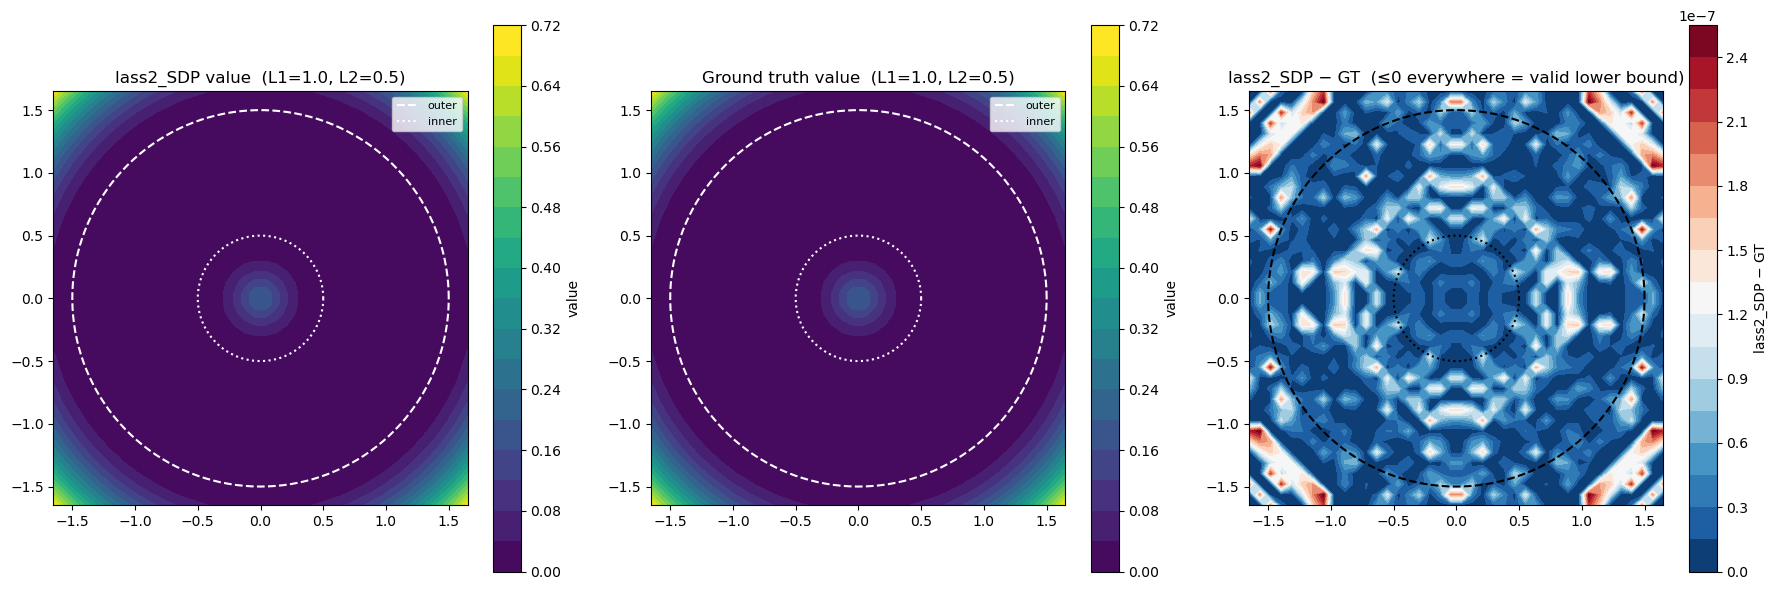

lass2_SDP − GT:  min=0.0000  max=0.0000


In [7]:
grid_n = 40
r_plot = (L1 + L2) * 1.1
xs     = np.linspace(-r_plot, r_plot, grid_n)
ys     = np.linspace(-r_plot, r_plot, grid_n)
XX, YY = np.meshgrid(xs, ys)

Z_relax = np.zeros((grid_n, grid_n))
Z_gt    = np.zeros((grid_n, grid_n))

grid_cache = {}
grid_args  = dict(ARGS, prob_cache=grid_cache)
for i in range(grid_n):
    for j in range(grid_n):
        p = np.array([XX[i, j], YY[i, j]])
        v, _ = (solve_lasserre2 if RELAXATION == "lass2_SDP" else solve_relaxation)(p, args=grid_args)
        Z_relax[i, j] = v if np.isfinite(v) else np.nan
        Z_gt[i, j]    = ground_truth(p, args=ARGS)

theta = np.linspace(0, 2 * np.pi, 300)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
vmax = max(np.nanmax(Z_relax), np.nanmax(Z_gt))

for ax, Z, title in zip(axes[:2],
                         [Z_relax, Z_gt],
                         [f"{RELAXATION} value", "Ground truth value"]):
    cf = ax.contourf(XX, YY, Z, levels=20, cmap="viridis", vmin=0, vmax=vmax)
    plt.colorbar(cf, ax=ax, label="value")
    ax.plot((L1+L2)*np.cos(theta), (L1+L2)*np.sin(theta), "w--", lw=1.5, label="outer")
    ax.plot(abs(L1-L2)*np.cos(theta), abs(L1-L2)*np.sin(theta), "w:", lw=1.5, label="inner")
    ax.set_aspect("equal")
    ax.set_title(f"{title}  (L1={L1}, L2={L2})")
    ax.legend(loc="upper right", fontsize=8)

Z_diff = Z_relax - Z_gt
cf3 = axes[2].contourf(XX, YY, Z_diff, levels=20, cmap="RdBu_r")
plt.colorbar(cf3, ax=axes[2], label=f"{RELAXATION} − GT")
axes[2].plot((L1+L2)*np.cos(theta), (L1+L2)*np.sin(theta), "k--", lw=1.5)
axes[2].plot(abs(L1-L2)*np.cos(theta), abs(L1-L2)*np.sin(theta), "k:", lw=1.5)
axes[2].set_aspect("equal")
axes[2].set_title(f"{RELAXATION} − GT  (≤0 everywhere = valid lower bound)")

plt.tight_layout()
plt.show()

print(f"{RELAXATION} − GT:  min={Z_diff[np.isfinite(Z_diff)].min():.4f}  "
      f"max={Z_diff[np.isfinite(Z_diff)].max():.4f}")

## Stage 2 — Generate training and test data

In [8]:
train_path = DATA_DIR / f"train_{N_TRAIN}_{RELAXATION}.csv"
test_path  = DATA_DIR / f"test_{N_TEST}_{RELAXATION}.csv"

if not train_path.exists():
    print(f"Generating {N_TRAIN} training samples ({RELAXATION})...")
    df_train = generate_dataset(N_TRAIN, args=ARGS)
    df_train.to_csv(train_path, index=False)
    print(f"  Saved to {train_path}")
else:
    df_train = pd.read_csv(train_path)
    print(f"Loaded training data from {train_path}")

if not test_path.exists():
    print(f"Generating {N_TEST} test samples ({RELAXATION} + local solver)...")
    test_seed_args = dict(ARGS, seed=SEED + 1)
    df_test = generate_test_dataset(N_TEST, args=test_seed_args)
    df_test.to_csv(test_path, index=False)
    print(f"  Saved to {test_path}")
else:
    df_test = pd.read_csv(test_path)
    print(f"Loaded test data from {test_path}")

print(f"\nTraining set: {len(df_train)} samples  [{RELAXATION}]")
print(f"  Exact (rank-1):      {df_train['Exact'].sum()} / {len(df_train)}")
print(f"  Cost range:          [{df_train['Cost'].min():.4f}, {df_train['Cost'].max():.4f}]")
print(f"  Reachable (Cost≈0):  {(df_train['Cost'] < 1e-4).sum()}")
print(f"\nTest set: {len(df_test)} samples")
print(f"  Relaxation–Local max gap: {(df_test['LocalCost'] - df_test['Cost']).max():.6f}")

Generating 10000 training samples (lass2_SDP)...
  Saved to /Users/charlesgulian/Desktop/Projects/nn-4-opt-cert/data/ik/train_10000_lass2_SDP.csv
Generating 5000 test samples (lass2_SDP + local solver)...
model.name="unknown";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.17\x3a Maximum Number of Iterations
      Exceeded.
model.name="unknown";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.17\x3a Maximum Number of Iterations
      Exceeded.
model.name="unknown";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.17\x3a Maximum Number of Iterations
      Exceeded.
model.name="unknown";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.17\x3a Maximum Number of Iterations
      Exceeded.
model.name="unknown";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.17\x3a Maximum Number of Iterations
      Exceeded.
model.name="unknown"

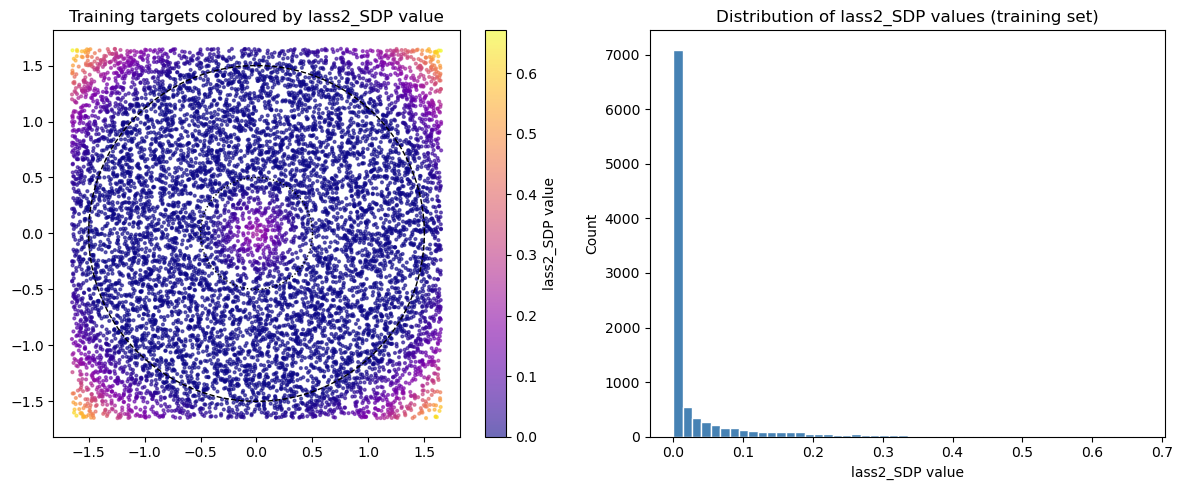

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc = axes[0].scatter(df_train["xd"], df_train["yd"], c=df_train["Cost"],
                     cmap="plasma", s=4, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label=f"{RELAXATION} value")
theta = np.linspace(0, 2 * np.pi, 300)
axes[0].plot((L1+L2)*np.cos(theta), (L1+L2)*np.sin(theta), "k--", lw=1)
axes[0].plot(abs(L1-L2)*np.cos(theta), abs(L1-L2)*np.sin(theta), "k:", lw=1)
axes[0].set_aspect("equal")
axes[0].set_title(f"Training targets coloured by {RELAXATION} value")

axes[1].hist(df_train["Cost"], bins=50, color="steelblue", edgecolor="white")
axes[1].set_xlabel(f"{RELAXATION} value")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Distribution of {RELAXATION} values (training set)")

plt.tight_layout()
plt.show()

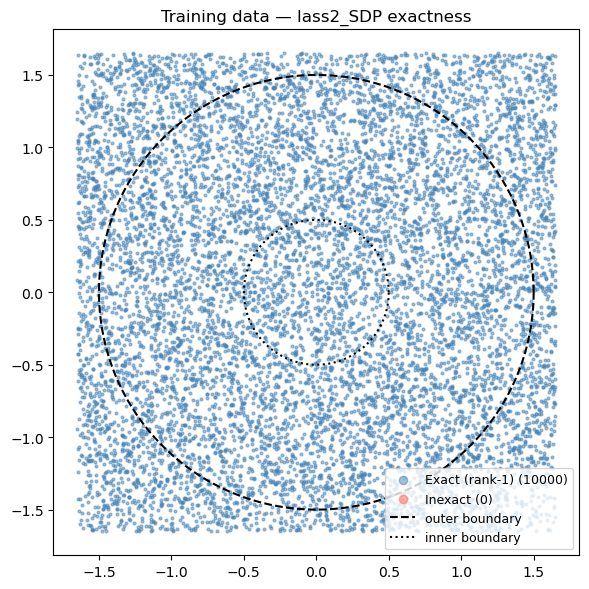

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))

for exact, label, color in [(True, "Exact (rank-1)", "steelblue"), (False, "Inexact", "tomato")]:
    mask = df_train["Exact"] == exact
    ax.scatter(df_train.loc[mask, "xd"], df_train.loc[mask, "yd"],
               c=color, s=4, alpha=0.5, label=f"{label} ({mask.sum()})")

theta = np.linspace(0, 2 * np.pi, 300)
ax.plot((L1+L2)*np.cos(theta), (L1+L2)*np.sin(theta), "k--", lw=1.5, label="outer boundary")
ax.plot(abs(L1-L2)*np.cos(theta), abs(L1-L2)*np.sin(theta), "k:", lw=1.5, label="inner boundary")
ax.set_aspect("equal")
ax.set_title(f"Training data — {RELAXATION} exactness")
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

## Stage 3 — Train DNN with 2-Fold cross-validation

Input: $(x_d, y_d)$ (2D). Output: SDP relaxation value (scalar). Two-phase training: large-batch pre-training then small-batch fine-tuning.

In [11]:
X_all = df_train[["xd", "yd"]].values.astype(np.float32)
y_all = df_train["Cost"].values.astype(np.float32)

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_all)):
    print(f"\n{'='*60}")
    print(f"Fold {fold + 1} / {N_FOLDS}")
    print(f"{'='*60}")

    X_tr, X_val = X_all[train_idx], X_all[val_idx]
    y_tr, y_val = y_all[train_idx], y_all[val_idx]

    model = DNN(input_dim=2, hidden_dims=HIDDEN_DIMS)

    model, train_losses, val_losses = train_model_two_phase(
        model, X_tr, X_val, y_tr, y_val,
        pretrain_epochs=PRETRAIN_EPOCHS,
        pretrain_lr=PRETRAIN_LR,
        pretrain_batch_size=PRETRAIN_BATCH_SIZE,
        finetune_epochs=FINETUNE_EPOCHS,
        finetune_lr=FINETUNE_LR,
        finetune_batch_size=FINETUNE_BATCH_SIZE,
        weight_decay=WEIGHT_DECAY,
        verbose=True,
    )

    fold_results.append({
        "fold":            fold,
        "model":           model,
        "train_losses":    train_losses,
        "val_losses":      val_losses,
        "phase_boundary":  PRETRAIN_EPOCHS,
        "val_idx":         val_idx,
    })


Fold 1 / 2


Fine-tuning: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:13<00:00, 14.78it/s]



Fold 2 / 2


Fine-tuning: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:13<00:00, 14.41it/s]


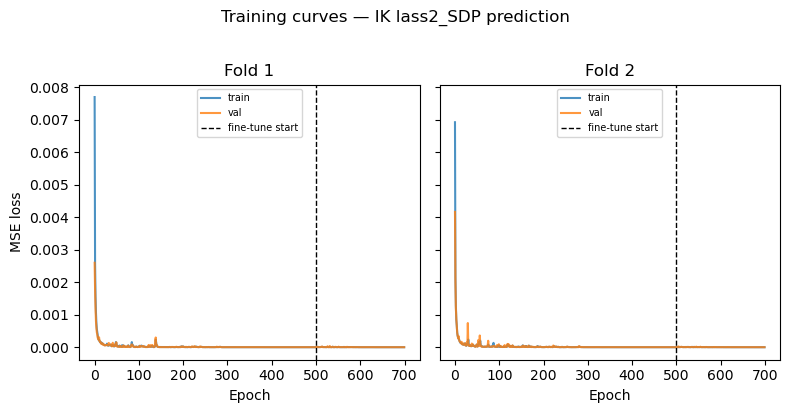

In [12]:
fig, axes = plt.subplots(1, N_FOLDS, figsize=(4 * N_FOLDS, 4), sharey=True)
for fold, res in enumerate(fold_results):
    ax = axes[fold]
    ax.plot(res["train_losses"], label="train", alpha=0.8)
    ax.plot(res["val_losses"],   label="val",   alpha=0.8)
    ax.axvline(res["phase_boundary"], color="k", lw=1, ls="--", label="fine-tune start")
    ax.set_title(f"Fold {fold + 1}")
    ax.set_xlabel("Epoch")
    if fold == 0:
        ax.set_ylabel("MSE loss")
    ax.legend(fontsize=7)
plt.suptitle(f"Training curves — IK {RELAXATION} prediction", y=1.02)
plt.tight_layout()
plt.show()

## Stage 4 — Evaluate on held-out test set

Compare DNN predictions against the true SDP value and the local QCQP optimal (upper bound). The DNN should provide a certificate: `LocalCost ≥ SDP ≥ DNN_pred` (if the DNN under-predicts) or at least track the SDP closely.

In [13]:
X_test = df_test[["xd", "yd"]].values.astype(np.float32)
y_relax = df_test["Cost"].values.astype(np.float32)
y_loc   = df_test["LocalCost"].values.astype(np.float32)

# Average predictions across folds (ensemble)
preds_per_fold = np.stack(
    [predict(res["model"], X_test) for res in fold_results], axis=0
)
y_pred = preds_per_fold.mean(axis=0)

print(f"Error summary — DNN vs {RELAXATION} (true label):")
print(error_summary(y_relax, y_pred))

print(f"\nRelaxation–Local gap ({RELAXATION} vs IPOPT):")
gap = y_loc - y_relax
print(f"  mean={gap.mean():.6f}  max={gap.max():.6f}  "
      f"tight (gap<1e-4): {(gap < 1e-4).mean()*100:.1f}%")

Error summary — DNN vs lass2_SDP (true label):
{'n': 5000, 'mean_abs_error': np.float32(0.0003685394), 'ci_lower': np.float64(0.00035540484239179865), 'ci_upper': np.float64(0.0003816739365195833), 'max_abs_error': np.float32(0.010872275)}

Relaxation–Local gap (lass2_SDP vs IPOPT):
  mean=nan  max=nan  tight (gap<1e-4): 96.6%


In [14]:
# Ground truth check: verify IPOPT local solutions against closed-form optimal
gt_vals = np.array([ground_truth([row.xd, row.yd], args=ARGS)
                    for _, row in df_test.iterrows()])
df_test["GT"] = gt_vals

local_gap = df_test["LocalCost"].values - gt_vals  # ≥ 0 if IPOPT is feasible
sdp_gap   = gt_vals - df_test["Cost"].values        # ≥ 0 if SDP is valid lower bound

print("Local solver vs ground truth:")
print(f"  max(LocalCost - GT): {local_gap.max():.6f}  (0 = globally optimal)")
print(f"  mean gap:            {local_gap.mean():.6f}")
print(f"  IPOPT globally optimal (gap < 1e-4): {(local_gap < 1e-4).mean()*100:.1f}%")

print()
print("SDP vs ground truth  (SDP should be a lower bound, i.e. SDP ≤ GT):")
print(f"  max(SDP - GT):  {(-sdp_gap).max():.6f}  (positive = SDP exceeds GT — bug if > tol)")
print(f"  SDP ≤ GT everywhere: {(sdp_gap >= -1e-5).all()}")

Local solver vs ground truth:
  max(LocalCost - GT): nan  (0 = globally optimal)
  mean gap:            nan
  IPOPT globally optimal (gap < 1e-4): 96.6%

SDP vs ground truth  (SDP should be a lower bound, i.e. SDP ≤ GT):
  max(SDP - GT):  0.000000  (positive = SDP exceeds GT — bug if > tol)
  SDP ≤ GT everywhere: True


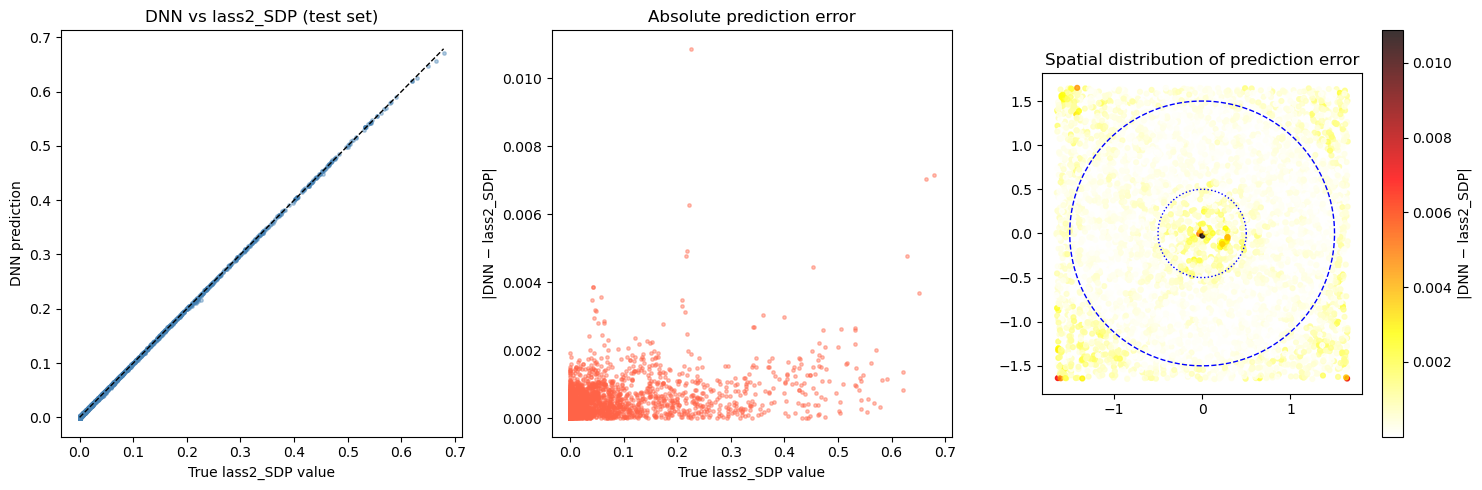

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vmax = max(y_relax.max(), y_pred.max())
axes[0].scatter(y_relax, y_pred, s=6, alpha=0.4, c="steelblue")
axes[0].plot([0, vmax], [0, vmax], "k--", lw=1)
axes[0].set_xlabel(f"True {RELAXATION} value")
axes[0].set_ylabel("DNN prediction")
axes[0].set_title(f"DNN vs {RELAXATION} (test set)")

abs_err = np.abs(y_pred - y_relax)
axes[1].scatter(y_relax, abs_err, s=6, alpha=0.4, c="tomato")
axes[1].set_xlabel(f"True {RELAXATION} value")
axes[1].set_ylabel(f"|DNN − {RELAXATION}|")
axes[1].set_title("Absolute prediction error")

sc = axes[2].scatter(df_test["xd"], df_test["yd"], c=abs_err,
                     cmap="hot_r", s=12, alpha=0.8)
plt.colorbar(sc, ax=axes[2], label=f"|DNN − {RELAXATION}|")
theta = np.linspace(0, 2 * np.pi, 300)
axes[2].plot((L1+L2)*np.cos(theta), (L1+L2)*np.sin(theta), "b--", lw=1)
axes[2].plot(abs(L1-L2)*np.cos(theta), abs(L1-L2)*np.sin(theta), "b:", lw=1)
axes[2].set_aspect("equal")
axes[2].set_title("Spatial distribution of prediction error")

plt.tight_layout()
plt.show()

## Stage 5 — Certify optimality of the local QCQP solver

For each test point, we compare:
- **Actually optimal**: `LocalCost − GT ≤ TOL` (IPOPT found the global optimum per closed-form ground truth)
- **Predicted optimal**: `LocalCost − Pred ≤ TOL` (DNN certifies the local solution is near-optimal, using the `RELAXATION` value as the lower bound)

A false positive means the DNN certifies a solution that is actually suboptimal; a false negative means the DNN unnecessarily flags a globally optimal solution for a restart.

In [16]:
from nn.metrics import optimality_confusion_matrix

TOL = 1e-2

df_test["Pred"] = y_pred

cm = optimality_confusion_matrix(df_test["GT"], df_test["LocalCost"], df_test["Pred"], tol=TOL)

print(f"Optimality certification — {RELAXATION}  (tol={TOL}), n={cm['n']}")
print(f"{'':>20} {'Predicted Optimal':>18} {'Predicted Suboptimal':>22}")
print(f"{'Actually Optimal':>20} {cm['tp']:>18} {cm['fn']:>22}")
print(f"{'Actually Suboptimal':>20} {cm['fp']:>18} {cm['tn']:>22}")
print()
print(f"False positive rate: {cm['fpr']:.4f}")
print(f"False negative rate: {cm['fnr']:.4f}")

Optimality certification — lass2_SDP  (tol=0.01), n=5000
                      Predicted Optimal   Predicted Suboptimal
    Actually Optimal               4852                      1
 Actually Suboptimal                  0                    147

False positive rate: 0.0000
False negative rate: 0.0002
